## Nội dung

- Feature engineering
- Phân cụm: KMeans, DBSCAN
- Kết hợp phân cụm và phân tích mô tả
- Kết hợp PCA và phân cụm
- Tập dữ liệu:
   1. Customer Personality Analysis (nguồn: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)
   2. Taxi geolocation (nguồn: https://www.coursera.org/projects/clustering-geolocation-data-intelligently-python)

#### Cài đặt thư viện

In [1]:
%pip install folium kneed yellowbrick

You should consider upgrading via the 'c:\Users\DUC THANG\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.



     -------------------------------------- 113.4/113.4 KB 1.6 MB/s eta 0:00:00
     -------------------------------------- 282.6/282.6 KB 4.4 MB/s eta 0:00:00
     ---------------------------------------- 98.8/98.8 KB 5.5 MB/s eta 0:00:00
     -------------------------------------- 134.9/134.9 KB 8.3 MB/s eta 0:00:00


### A. Customer Personality Analysis

#### A1. Đọc dữ liệu

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler

In [3]:
pd.set_option('display.max_columns', None)
customer_data = pd.read_csv('data/marketing_campaign.csv',
                           delimiter='\t', index_col='ID')
customer_data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


#### A2. Làm sạch
- Làm sạch dữ liệu.
- Trích xuất đặc trưng (đọc thêm: https://machinelearningcoban.com/general/2017/02/06/featureengineering/)

In [4]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   object 
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int

Dữ liệu khá sạch và chỉ có 1 số lượng nhỏ income bị thiếu dữ liệu, có thể xử lý bằng cách thêm vào mean. Mã hoá 1 số đặc trưng kiểu loại.

In [5]:
customer_data['Income'] = customer_data['Income'].fillna(customer_data['Income'].mean())

#### A3. Feature engineering

In [6]:
import datetime

Đầu tiên là dữ liệu liên quan ngày tháng.

- `Year_Birth` không phải là đặc trưng lý tưởng cho bài toán này, ta sẽ chuyển nó sang thành tuổi `Age` (tính từ hiện tại)

In [7]:
# Trích xuất tuổi từ đặc trưng năm sinh
# hint: 2022 - x
customer_data['Age'] = 2022 - customer_data['Year_Birth']

- `Days_Since_Customer`, tương tự như `Year_Birth`, nên được chuyển thành số ngày đã tham gia `Enroll_days`.

In [10]:
# Đặc trưng 'Days_Since_Customer' ~ ngày tham gia, biến đổi thành số lượng ngày đã tham gia
customer_data['Dt_Customer'] = pd.to_datetime(customer_data['Dt_Customer'], format='%d-%m-%Y')
now = datetime.datetime.now()
customer_data['Enroll_days'] = (now - customer_data['Dt_Customer']).dt.days

- Các đặc trưng `Marital_Status`, `Kidhome`, `Teenhome` có thể được gom lại 1 thuộc tính duy nhất --> cô động hơn

In [11]:
customer_data['Fam_size'] = customer_data['Kidhome'] + customer_data['Teenhome'] + 1

- Gom các đặc trưng `AcceptedCmpX` thành 1 đặc trưng `Num_Accepted` (tổng)
- Làm tương tự cho các đặc trưng MntX, gom thành đặc trưng `MntTotal`

In [12]:
accepted_columns = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
customer_data['Num_Accepted'] = customer_data[accepted_columns].sum(axis=1)

In [13]:
spending_columns = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
customer_data['MntTotal'] = customer_data[spending_columns].sum(axis=1)

#### A4. Phân tích EDA

In [14]:
customer_data.describe()

,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_size,Num_Accepted,MntTotal
count,2240.000000,2240.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,52247.251354,0.444196,0.506250,2013-07-10 10:01:42.857142784,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,53.194196,4835.582143,1.950446,0.297768,605.798214
min,1893.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,26.000000,4482.000000,1.000000,0.000000,5.000000
25%,1959.000000,35538.750000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,45.000000,4662.750000,1.000000,0.000000,68.750000
50%,1970.000000,51741.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,52.000000,4837.500000,2.000000,0.000000,396.000000
75%,1977.000000,68289.750000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,63.000000,5011.000000,2.000000,0.000000,1045.500000
max,1996.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,129.000000,5181.000000,4.000000,4.000000,2525.000000
std,11.984069,25037.797168,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,11.984069,202.122512,0.751803,0.678381,602.249288


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

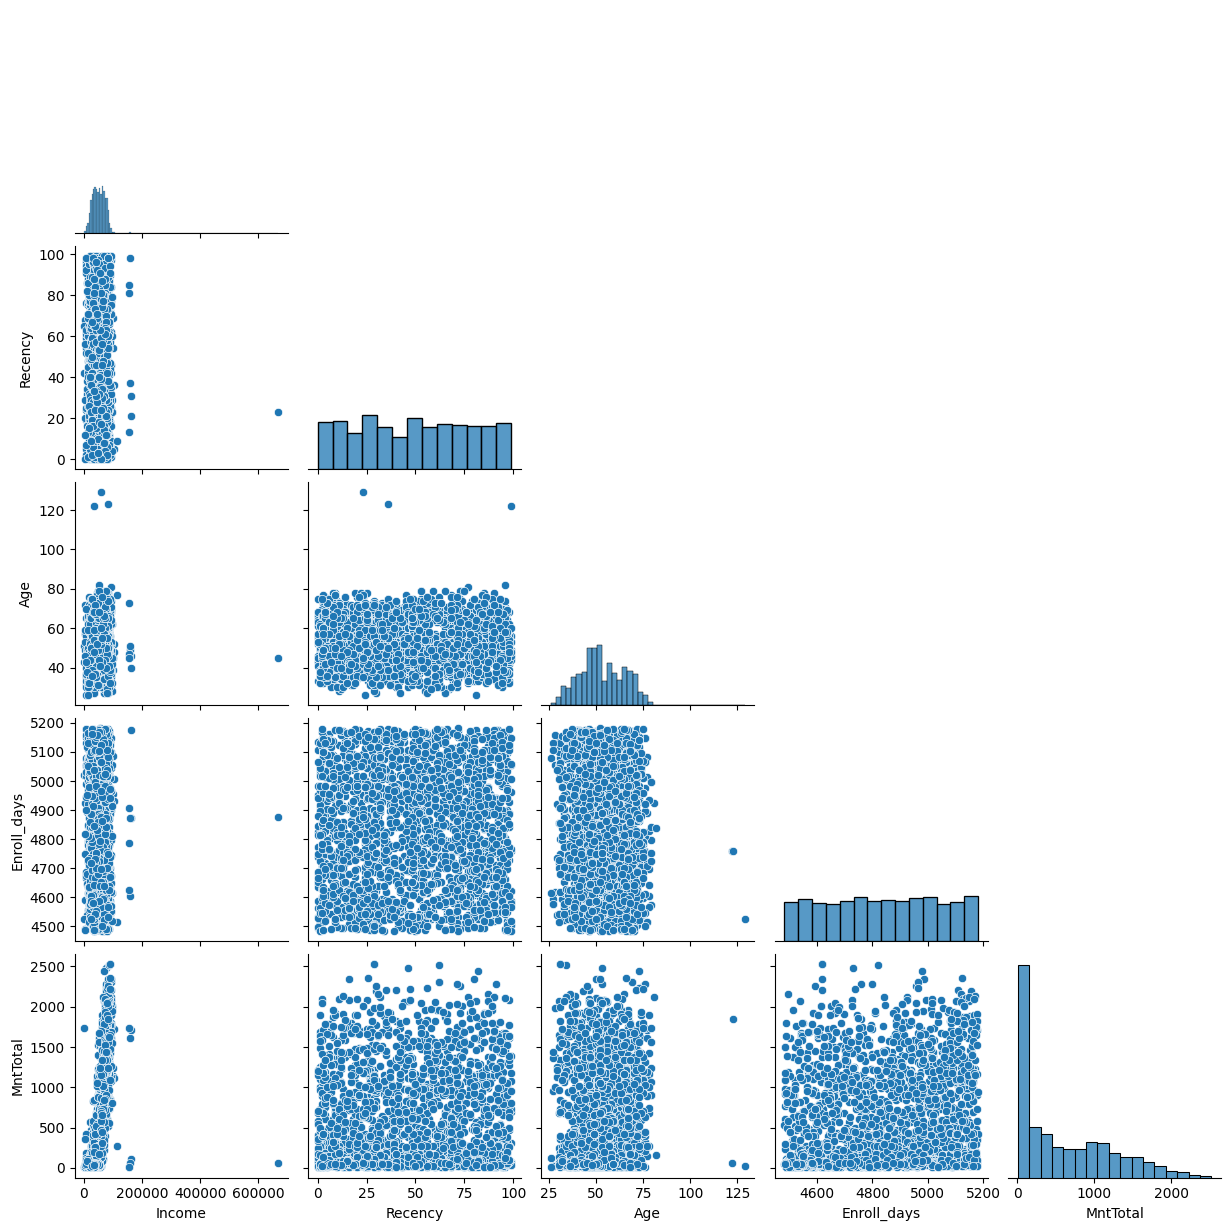

In [16]:
plot_cols = ['Income', 'Recency', 'Age', 'Enroll_days', 'MntTotal']
sns.pairplot(customer_data[plot_cols], corner=True, diag_kind='hist')
plt.show()

In [17]:
income_q1 = customer_data['Income'].quantile(0.25)
income_q3 = customer_data['Income'].quantile(0.75)
income_upper = income_q3 + 1.5 * (income_q3 - income_q1)
rows_before_filter = len(customer_data)
customer_data = customer_data.loc[customer_data['Income'] <= income_upper].copy()
print('Số dòng Income ngoại lệ đã loại:', rows_before_filter - len(customer_data))

Số dòng Income ngoại lệ đã loại: 8


In [18]:
df = customer_data.copy()

df.drop([
    'Dt_Customer', 'Year_Birth',
    'Kidhome', 'Teenhome', 'Marital_Status',
    'Z_CostContact', 'Z_Revenue',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4', 'AcceptedCmp5',
    'Complain', 'Response', 'Education', 'Num_Accepted'
], axis=1, inplace=True)

#### A5. Tiền xử lý

**Mã hoá đặc trưng kiểu loại**

In [19]:
df = pd.get_dummies(df, drop_first=True, dtype=int)
print(df.select_dtypes(include='object').columns.tolist())

[]


**Chuẩn hoá các thuộc tính kiểu số**

In [20]:
scaler = StandardScaler()
df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)

In [21]:
df.describe() # --> Kiểm tra mean và std có gần với giá trị (0, 1)?

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Enroll_days,Fam_size,MntTotal
count,2.232000e+03,2.232000e+03,2.232000e+03,2.232000e+03,2.232000e+03,2.232000e+03,2.232000e+03,2.232000e+03,2.232000e+03,2.232000e+03,2.232000e+03
mean,2.498997e-16,-1.030637e-16,-5.252668e-17,-1.209705e-16,-6.685214e-17,-1.591718e-18,6.685214e-17,1.317146e-16,8.690778e-16,-4.138466e-17,3.660950e-17
std,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00
min,-2.423163e+00,-1.696622e+00,-1.223808e+00,-1.477114e+00,-9.430722e-01,-1.791854e+00,-2.207921e+00,-2.269622e+00,-1.748714e+00,-1.266161e+00,-9.988141e-01
25%,-7.867831e-01,-8.675036e-01,-6.958722e-01,-7.561611e-01,-9.430722e-01,-8.663485e-01,-9.655478e-01,-6.846575e-01,-8.547430e-01,-1.266161e+00,-8.923797e-01
50%,-3.604195e-03,-3.838511e-03,-1.679365e-01,-3.520784e-02,-2.275939e-01,-2.493447e-01,2.768250e-01,-1.007234e-01,7.079814e-03,6.438104e-02,-3.477350e-01
75%,8.000023e-01,8.598265e-01,3.599992e-01,6.857454e-01,4.878844e-01,6.761609e-01,6.909493e-01,8.168874e-01,8.676661e-01,6.438104e-02,7.294974e-01
max,3.014678e+00,1.723492e+00,6.695228e+00,8.255755e+00,9.073623e+00,2.218670e+00,6.074565e+00,6.322552e+00,1.708469e+00,2.725464e+00,3.192040e+00


#### A6. Phân cụm KMeans

In [22]:
from sklearn.cluster import KMeans

Phương pháp Elbow: ước lượng số cụm

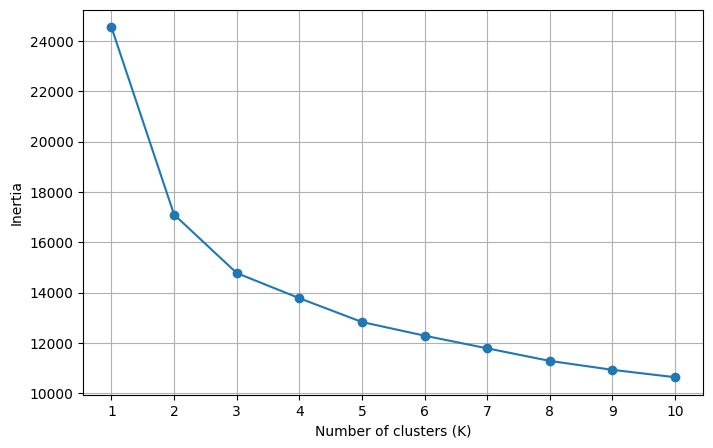

In [23]:
inertias = []
cluster_counts = range(1, 11)
for cluster_count in cluster_counts:
    model = KMeans(n_clusters=cluster_count, n_init=10, random_state=99)
    model.fit(df)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(cluster_counts, inertias, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.xticks(list(cluster_counts))
plt.grid(True)
plt.show()

Sử dụng thư viện yellowbrick

In [24]:
from yellowbrick.cluster import KElbowVisualizer

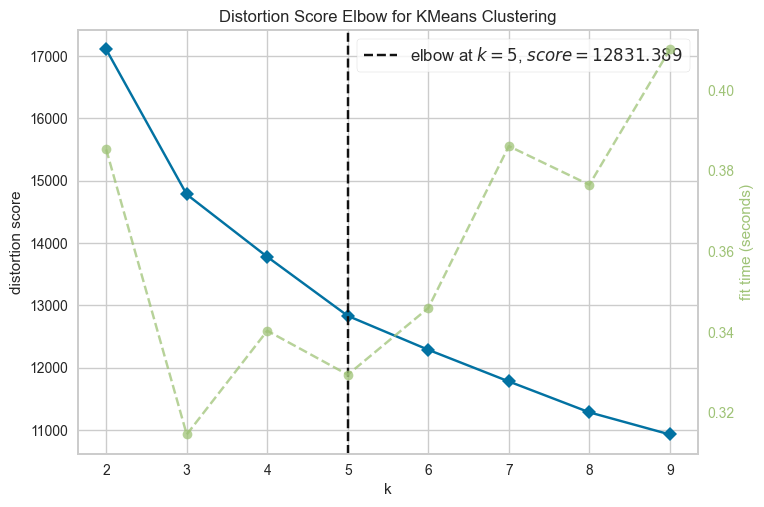

K theo elbow: 5


In [25]:
model = KMeans(n_init=20, random_state=99)
visualizer = KElbowVisualizer(model, k=(2, 10), metric='distortion')
visualizer.fit(df)
visualizer.show()
print('K theo elbow:', visualizer.elbow_value_)

**Phân cụm từ kết quả của phương pháp Elbow**

In [26]:
selected_k = visualizer.elbow_value_ or 4
kmean = KMeans(n_clusters=selected_k, n_init=20, random_state=99)
kmean.fit(df)
print('KMeans fitted with K =', selected_k)

KMeans fitted with K = 5


**Sử dụng PCA giảm số chiều dữ liệu --> trực quan hoá kết quả phân cụm**

In [27]:
from sklearn.decomposition import PCA

In [28]:
# Biến đổi dữ liệu sang không gian 2 chiều PCA
pca_2d = PCA(n_components=2, random_state=99)
scores = pca_2d.fit_transform(df)
print('Tỷ lệ phương sai 2 thành phần:', pca_2d.explained_variance_ratio_.sum())

Tỷ lệ phương sai 2 thành phần: 0.5437279986834085


**Trực quan hoá kết quả phân cụm**

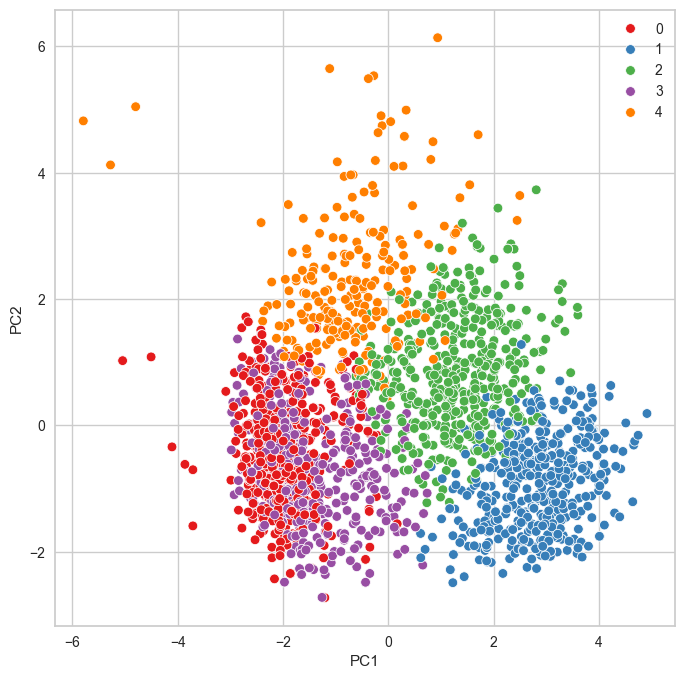

In [29]:
def visualize_cluster_result(scores, labels):
    '''
    Args:
        scores: dữ liệu đã giảm xuống không gian PCA 2D.
        labels: nhãn cụm của từng điểm dữ liệu.
    '''
    fig, axes = plt.subplots(figsize=(8, 8))
    sns.scatterplot(
        x=scores[:, 0],
        y=scores[:, 1],
        hue=labels,
        ax=axes,
        palette='Set1',
        legend='full'
    )
    axes.set_xlabel('PC1')
    axes.set_ylabel('PC2')
    plt.show()


visualize_cluster_result(scores, kmean.labels_)

#### Phân tích kết quả phân cụm (KMeans)

In [30]:
kmean_df = customer_data.copy()
kmean_df['Fam_size'] = customer_data['Kidhome'] + customer_data['Teenhome'] + 1
kmean_df['MntTotal'] = customer_data[spending_columns].sum(axis=1)
kmean_df['Cluster'] = kmean.labels_
kmean_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,65,5145,1,0,1617,2
2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,68,4595,3,0,27,3
4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,57,4794,1,0,776,2
6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,38,4621,2,0,53,0
5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,41,4643,2,0,422,4


In [31]:
def visualize_cluster_distribution(labels):
    '''
    Args:
        labels: kết quả phân cụm (danh sách nhãn)
    '''
    ulabels, count = np.unique(labels, return_counts=True)
    plt.figure(figsize=(6,4))

    colors = sns.color_palette('Set2')[0:5]
    
    labels = [f'Cluster {i+1}' for i in range(len(ulabels))]
    plt.pie(count, 
            explode=[0.05]*len(ulabels), 
            labels=labels,
            colors=colors,
            autopct='%1.1f%%',
            textprops=dict(color ="white", fontsize=10),
            counterclock=False,
            startangle=180,
            wedgeprops={"edgecolor":"gray",'linewidth': 1}
        )

    plt.axis('equal')
    plt.legend()
    plt.show()

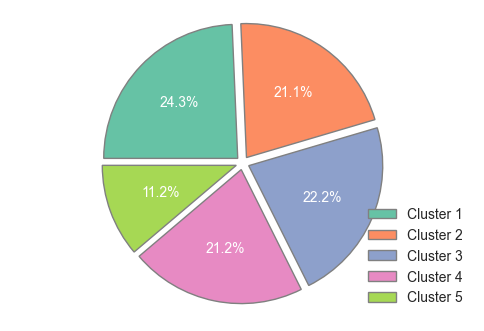

In [32]:
visualize_cluster_distribution(kmean.labels_)

**Phân tích đa biến + kết quả phân cụm**

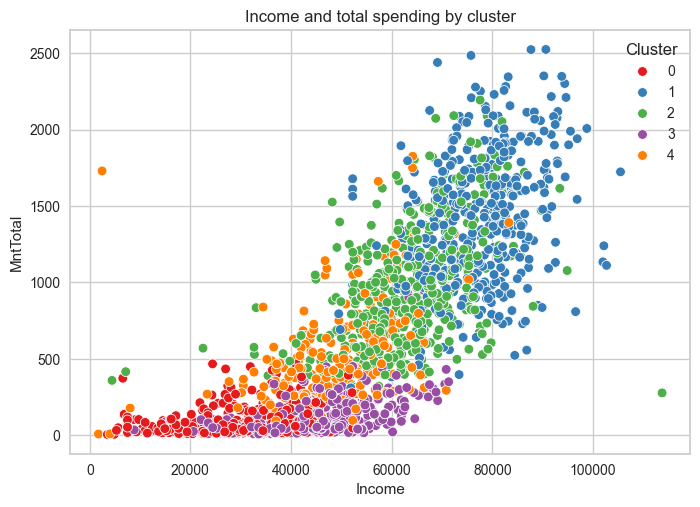

In [33]:
sns.scatterplot(data=kmean_df, x='Income', y='MntTotal', hue='Cluster', palette='Set1')
plt.title('Income and total spending by cluster')
plt.show()

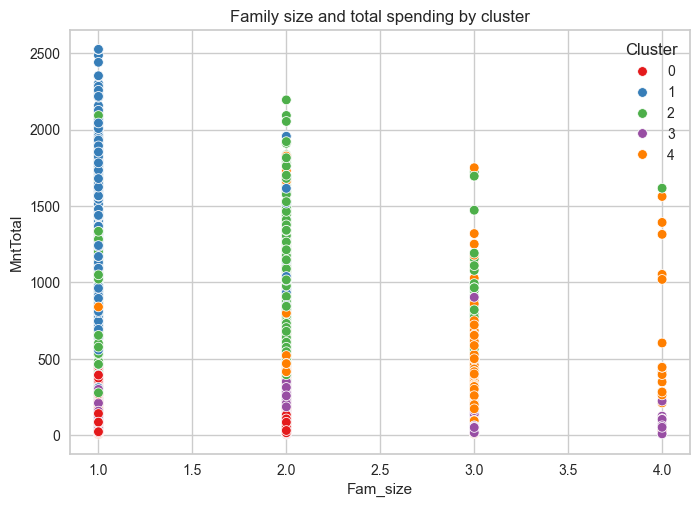

In [34]:
sns.scatterplot(data=kmean_df, x='Fam_size', y='MntTotal', hue='Cluster', palette='Set1')
plt.title('Family size and total spending by cluster')
plt.show()

**Phân tích danh mục mua hàng**

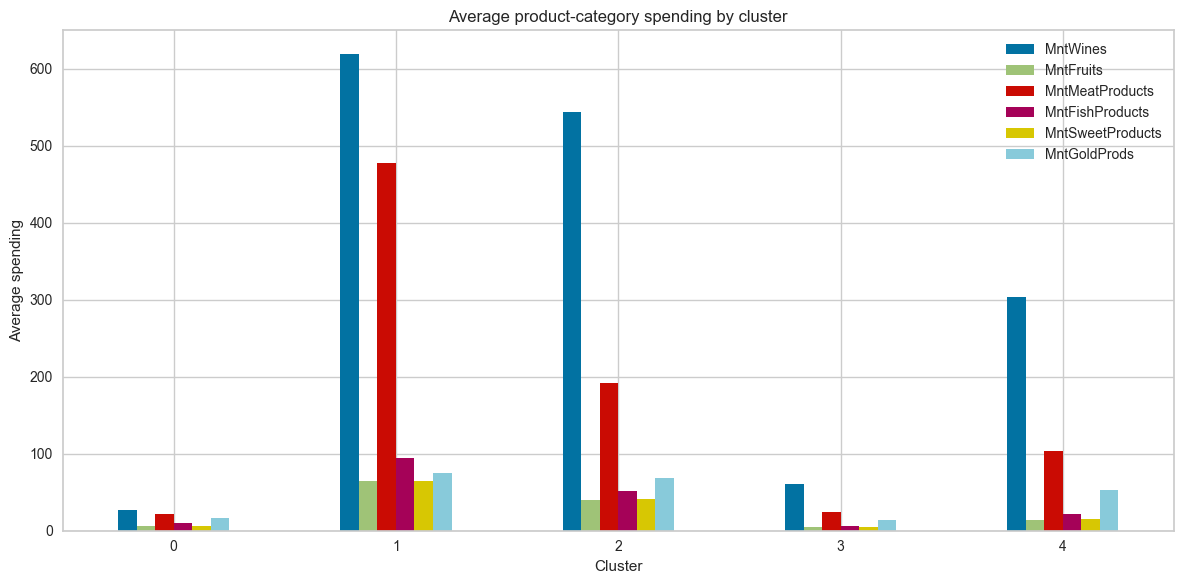

In [35]:
spending_columns = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
cluster_spending = kmean_df.groupby('Cluster')[spending_columns].mean()
cluster_spending.plot(kind='bar', figsize=(12, 6))
plt.ylabel('Average spending')
plt.title('Average product-category spending by cluster')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### A7. Kết hợp PCA và phân cụm
- Biến đổi PCA với số lượng component phù hợp (giữ lại 70-80% thông tin ban đầu).
- Ước lượng số cụm dùng elbow (dùng dữ liệu pca).
- Với số cụm phù hợp, thực hiện phân cụm trên dữ liệu pca.
- Vẽ phân bố kết quả phân cụm.
- Vẽ biểu đồ scatter MntTotal-Income-Cluster.

In [36]:
# vẽ biểu đồ sreeplot
def scree_plot(pca_model, xlabels):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # explained variance ratio của mô hình pca
    expl_var_ratio = pca_model.explained_variance_ratio_
    # tính cumulative sum của expl_var_ratio (numpy.cumsum)
    expl_var_cumsum = np.cumsum(expl_var_ratio)
    xtick_indx = range(1, len(expl_var_ratio) + 1)
    
    # vẽ các bar thể hiện explained_var
    ax.bar(xtick_indx, expl_var_ratio)
    ax.plot(xtick_indx, expl_var_cumsum, marker='o', color='k')
    
    # set label
    ax.set_xticks(xtick_indx)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel('Principle Components')
    ax.set_ylabel('% variance')
    ax.set_title('Scree Plot')
    
    plt.grid(True)

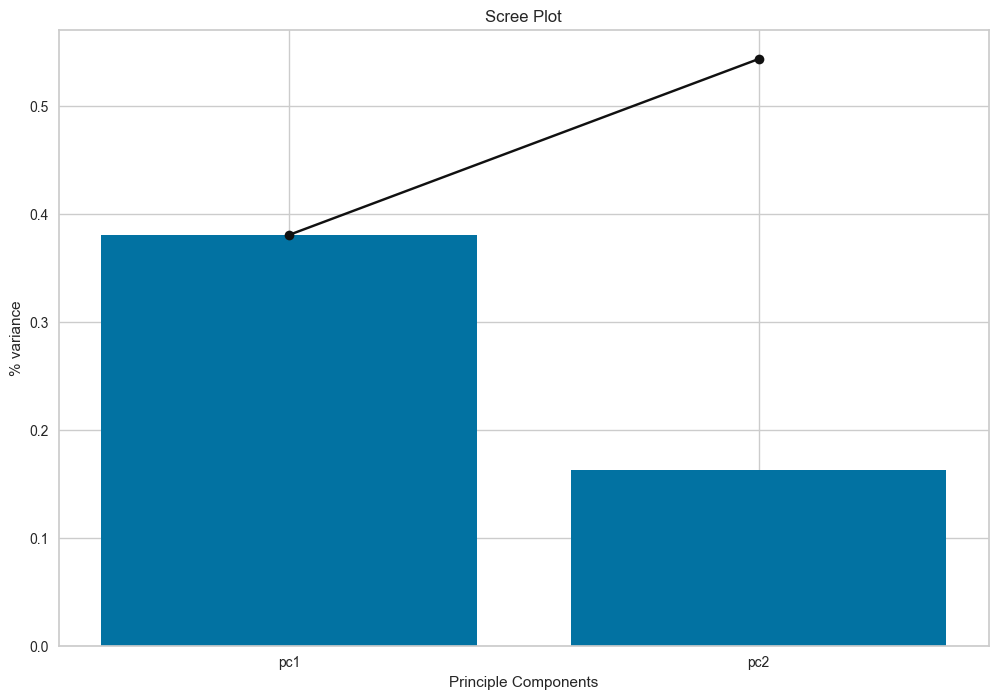

In [37]:
scree_plot(pca_2d, [f'pc{i + 1}' for i in range(len(pca_2d.explained_variance_ratio_))])

In [38]:
# Biến đổi df sang không gian PCA giữ lại ít nhất 75% phương sai
pca = PCA(n_components=0.75, svd_solver='full', random_state=99)
pca_transformed_4d = pca.fit_transform(df)
print('Số thành phần:', pca.n_components_)
print('Tỷ lệ phương sai giữ lại:', pca.explained_variance_ratio_.sum())

Số thành phần: 5
Tỷ lệ phương sai giữ lại: 0.8138593665834787


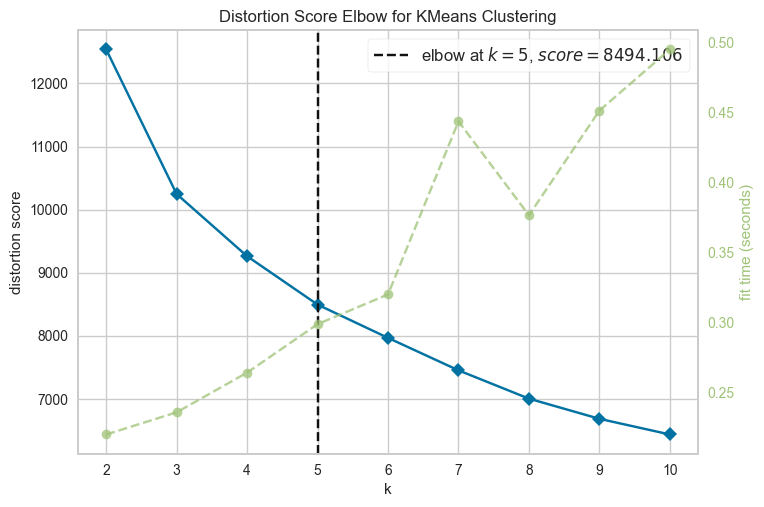

K trên dữ liệu PCA: 5


In [39]:
model = KMeans(n_init=20, random_state=99)
visualizer = KElbowVisualizer(model, k=10)
visualizer.fit(pca_transformed_4d)
visualizer.show()

selected_k_pca = visualizer.elbow_value_ or 4
kmean = KMeans(n_clusters=selected_k_pca, n_init=20, random_state=99)
kmean.fit(pca_transformed_4d)
print('K trên dữ liệu PCA:', selected_k_pca)

In [40]:
kmean_pca_df = customer_data.copy()
kmean_pca_df['Fam_size'] = customer_data['Kidhome'] + customer_data['Teenhome'] + 1
kmean_pca_df['MntTotal'] = customer_data[spending_columns].sum(axis=1)
kmean_pca_df['Cluster'] = kmean.labels_
kmean_pca_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,65,5145,1,0,1617,3
2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,68,4595,3,0,27,4
4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,57,4794,1,0,776,2
6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,38,4621,2,0,53,1
5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,41,4643,2,0,422,3


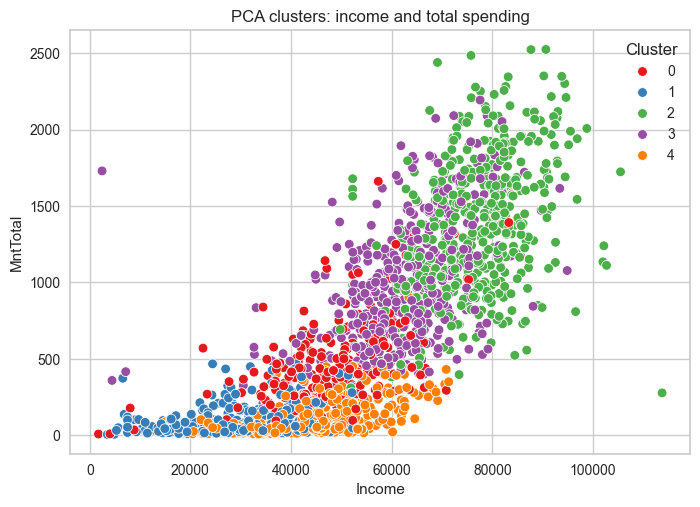

In [41]:
sns.scatterplot(data=kmean_pca_df, x='Income', y='MntTotal', hue='Cluster', palette='Set1')
plt.title('PCA clusters: income and total spending')
plt.show()

#### A9. Phân tích kết quả phân cụm (DBSCAN)

In [42]:
from sklearn.cluster import DBSCAN

**Sử dụng knee plot để ước lượng eps**

In [43]:
len(df.columns)

11

In [44]:
from sklearn.neighbors import NearestNeighbors


def knee_plot(n_neighs, data):
    neigh = NearestNeighbors(n_neighbors=n_neighs)
    neigh.fit(data)
    distances, _ = neigh.kneighbors(data)
    kth_distances = np.sort(distances[:, -1])
    plt.plot(kth_distances)
    plt.xlabel('Samples ordered by distance')
    plt.ylabel(f'Distance to neighbor {n_neighs}')
    plt.grid(True)
    return kth_distances

**Sử dụng PCA thu giảm số chiều --> phân cụm**

**Chia nhỏ đặc trưng**

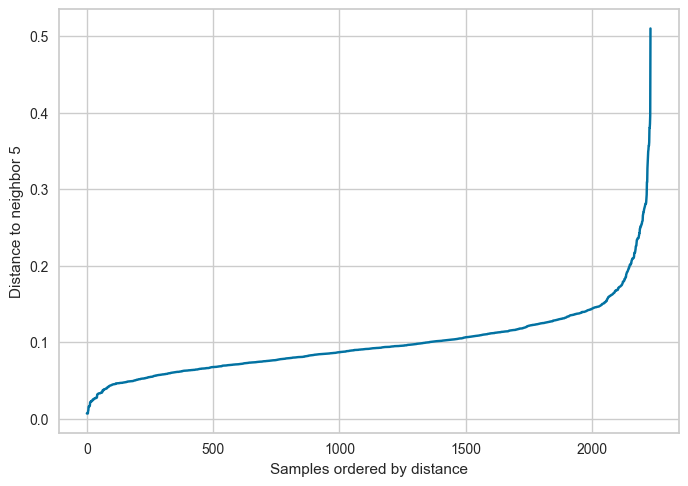

eps: 0.3800282614679706
number of clusters/noise: (array([-1,  0]), array([   1, 2231]))


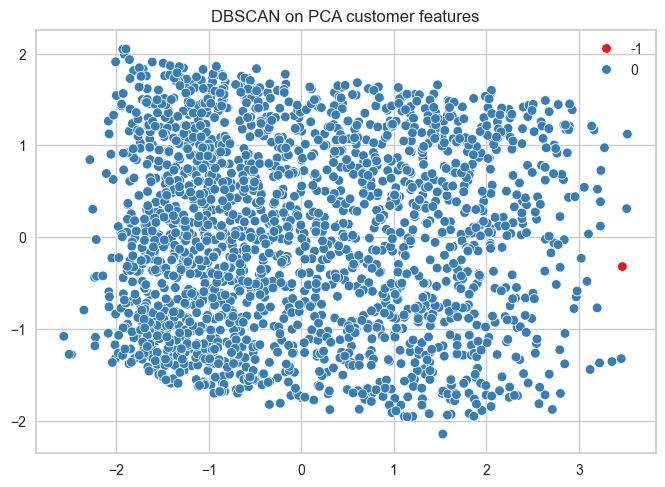

In [45]:
from kneed import KneeLocator

sub_df = df[['Income', 'MntTotal', 'Enroll_days']]
dbscan_pca = PCA(n_components=0.8, svd_solver='full', random_state=99)
dbscan_scores = dbscan_pca.fit_transform(sub_df)
distances = knee_plot(5, dbscan_scores)
plt.show()
knee = KneeLocator(range(len(distances)), distances, curve='convex', direction='increasing')
eps = knee.knee_y if knee.knee_y is not None else float(np.quantile(distances, 0.95))
dbscan_labels = DBSCAN(eps=eps, min_samples=5).fit_predict(dbscan_scores)
print('eps:', eps)
print('number of clusters/noise:', np.unique(dbscan_labels, return_counts=True))
sns.scatterplot(x=dbscan_scores[:, 0], y=dbscan_scores[:, 1], hue=dbscan_labels, palette='Set1')
plt.title('DBSCAN on PCA customer features')
plt.show()

### B. Dữ liệu taxi 

In [46]:
import pandas as pd

In [47]:
df = pd.read_csv('data/taxi_data.csv')
df.head()

,LON,LAT,NAME
0,28.17858,-25.73882,11th Street Taxi Rank
1,28.17660,-25.73795,81 Bazaar Street Taxi Rank
2,27.83239,-26.53722,Adams Road Taxi Rank
3,28.12514,-26.26666,Alberton City Mall Taxi Rank
4,28.10144,-26.10567,Alexandra Main Taxi Rank


**Biểu diễn giá trị toạ độ trên bản đồ**

In [48]:
import folium, re

In [52]:
coordinates = df[['LAT', 'LON']].apply(pd.to_numeric, errors='coerce')
valid_coordinates = np.isfinite(coordinates.to_numpy(dtype=float)).all(axis=1)
valid_coordinates &= coordinates['LAT'].between(-90, 90) & coordinates['LON'].between(-180, 180)
invalid_count = int((~valid_coordinates).sum())
df = df.loc[valid_coordinates].copy()
df[['LAT', 'LON']] = coordinates.loc[valid_coordinates].astype(float)
print('Rows removed for invalid coordinates:', invalid_count)

X = df[['LAT', 'LON']].to_numpy(dtype=float)
m = folium.Map(location=[X[:, 0].mean(), X[:, 1].mean()], tiles='OpenStreetMap', zoom_start=10)

Rows removed for invalid coordinates: 0


In [53]:
for _,row in df.iterrows():
    folium.CircleMarker(
        location=[row.LAT,row.LON],
        radius=5,
        popup=re.sub(r'\W+',' ',row.NAME),
        fill=True
    ).add_to(m)

# Loại bỏ non-word chars
title = '''<h3 align="center" style="font-size:30px"><b>Given Data</b></h3>'''
m.get_root().html.add_child(folium.Element(title))
m

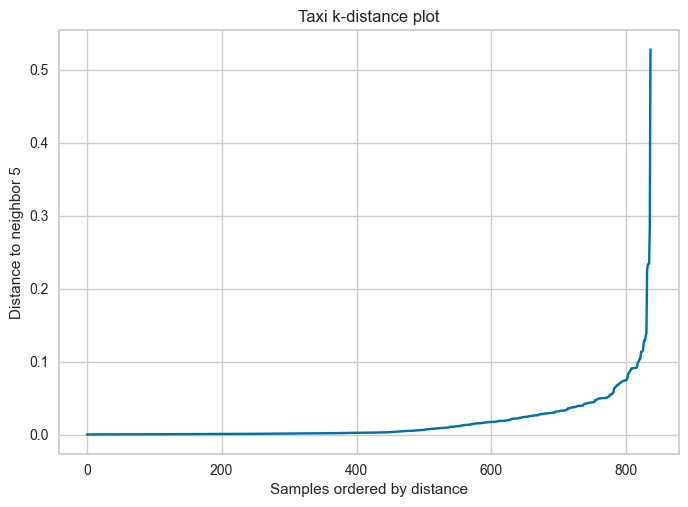

Estimated eps: 0.09153039822922412


In [54]:
taxi_distances = knee_plot(5, X)
plt.title('Taxi k-distance plot')
plt.show()
taxi_knee = KneeLocator(range(len(taxi_distances)), taxi_distances, curve='convex', direction='increasing')
taxi_eps = taxi_knee.knee_y if taxi_knee.knee_y is not None else float(np.quantile(taxi_distances, 0.95))
print('Estimated eps:', taxi_eps)

In [55]:
#First create an array of color schemes
colors = ['royalblue', 'maroon', 'forestgreen', 'mediumorchid', 'tan', 'deeppink', 
          'olive', 'goldenrod', 'lightcyan', 'navy','springgreen','midnightblue',
         'red','brown','limegreen','lime','pink','orchid','crimson','m']*10

In [56]:
taxi_labels = DBSCAN(eps=taxi_eps, min_samples=5).fit_predict(X)
df['Cluster'] = taxi_labels
unique_clusters = [label for label in np.unique(taxi_labels) if label != -1]
color_by_cluster = {-1: 'black'}
color_by_cluster.update({label: colors[index % len(colors)] for index, label in enumerate(unique_clusters)})
df['Color'] = df['Cluster'].map(color_by_cluster)
print('Clusters and noise:', np.unique(taxi_labels, return_counts=True))

Clusters and noise: (array([-1,  0,  1,  2,  3,  4,  5,  6]), array([ 15, 773,   5,  19,   6,   8,   5,   6]))


In [58]:
def create_map(cluster_column, colors_column, title):
    m = folium.Map(location=[X[:, 0].mean(), X[:, 1].mean()], tiles='OpenStreetMap', zoom_start=8.5)
    for _, row in df.iterrows():
        folium.CircleMarker(
            location=[row.LAT, row.LON],
            radius=5,
            popup=str(row[cluster_column]),
            fill=True,
            color=row[colors_column],
            fill_color=row[colors_column],
        ).add_to(m)

    print(title)
    return m

In [59]:
create_map('Cluster', 'Color', f'Taxi DBSCAN clusters (eps={taxi_eps:.4f})')

Taxi DBSCAN clusters (eps=0.0915)
